# Step 3 – Improved CNN

**Goal:** reduce the overfitting seen in the baseline and learn more general features.

| Change | Why |
|---|---|
| Random flips and 90° rotations | Satellite images have no "up": a rotated field is still a field. This multiplies the effective training data. |
| Small random contrast changes | Lighting and atmosphere differ between acquisition dates. |
| Batch normalisation | Stabilises and speeds up training of deeper networks. |
| Two convolutions per block, 7 in total | More capacity to learn textures (roof patterns, field stripes). |
| Global average pooling instead of Flatten + Dense | Far fewer parameters, so less memorisation. |
| Dropout 0.4, learning-rate reduction on plateau | Further regularisation and finer convergence. |

In [ ]:
# Setup: make the project package importable and fix random seeds
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from eurosat_cnn.config import CLASSES, DATA_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, SEED
keras.utils.set_random_seed(SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Keras", keras.__version__, "| data folder:", DATA_DIR)

## Settings

In [2]:
EPOCHS = 30
BATCH_SIZE = 64
FRACTION = 1.0

In [3]:
from eurosat_cnn.data import load_splits
from eurosat_cnn.models import build_model, RandomRot90

(train, train_ds), (val, val_ds), (test, test_ds) = load_splits(DATA_DIR, BATCH_SIZE, FRACTION)
print(f"train={len(train):,}  val={len(val):,}")

train=18,899  val=4,051


## 3.1 What data augmentation does
The same training tile, passed eight times through the augmentation layers:

In [ ]:
augment = keras.Sequential([keras.layers.RandomFlip("horizontal_and_vertical"), RandomRot90(),
                            keras.layers.RandomContrast(0.1)])
images, _ = next(iter(train_ds))
tile = images[:1]
fig, axes = plt.subplots(1, 9, figsize=(14, 2))
axes[0].imshow(tile[0]); axes[0].set_title("original", fontsize=9)
for ax in axes[1:]:
    ax.imshow(np.clip(augment(tile, training=True)[0], 0, 1)); ax.set_title("augmented", fontsize=9)
for ax in axes: ax.axis("off")
plt.savefig(FIGURES_DIR / "augmentation_examples.png", dpi=150, bbox_inches="tight"); plt.show()

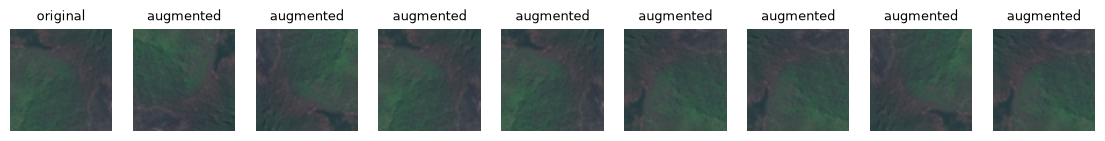

## 3.2 Build the model

In [5]:
model = build_model("improved")
model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rot90_1 (RandomRot90)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 64, 64, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             

 Total params: 577,514 (2.20 MB)

 Trainable params: 576,170 (2.20 MB)

 Non-trainable params: 1,344 (5.25 KB)

## 3.3 Train

In [ ]:
import json, time, tensorflow as tf

callbacks = [
    keras.callbacks.ModelCheckpoint(MODELS_DIR / "improved.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    keras.callbacks.CSVLogger(REPORTS_DIR / "improved_history.csv"),
]
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
minutes = (time.time() - start) / 60
info = {"model": "improved", "parameters": int(model.count_params()), "epochs_run": len(history.history["loss"]),
        "best_val_accuracy": float(max(history.history["val_accuracy"])), "training_minutes": round(minutes, 1),
        "hardware": "GPU" if tf.config.list_physical_devices("GPU") else "CPU",
        "settings": {"epochs": EPOCHS, "batch_size": BATCH_SIZE, "fraction": FRACTION}}
(REPORTS_DIR / "improved_training.json").write_text(json.dumps(info, indent=2))
info

Epoch 30/30
296/296 - 555s - 2s/step - accuracy: 0.9766 - loss: 0.0697 - val_accuracy: 0.9691 - val_loss: 0.0995 - learning_rate: 1.2500e-04

'model': 'improved',
 'parameters': 577514,
 'epochs_run': 30,
 'best_val_accuracy': 0.9725993871688843,
 'training_minutes': 162.1,
 'hardware': 'CPU',
 'settings': {'epochs': 30, 'batch_size': 64, 'fraction': 1.0}

## 3.4 Compare with the baseline
*Note:* validation accuracy can be low in the first one or two epochs of a batch-normalised model while its running statistics settle. Judge the curve as a whole.

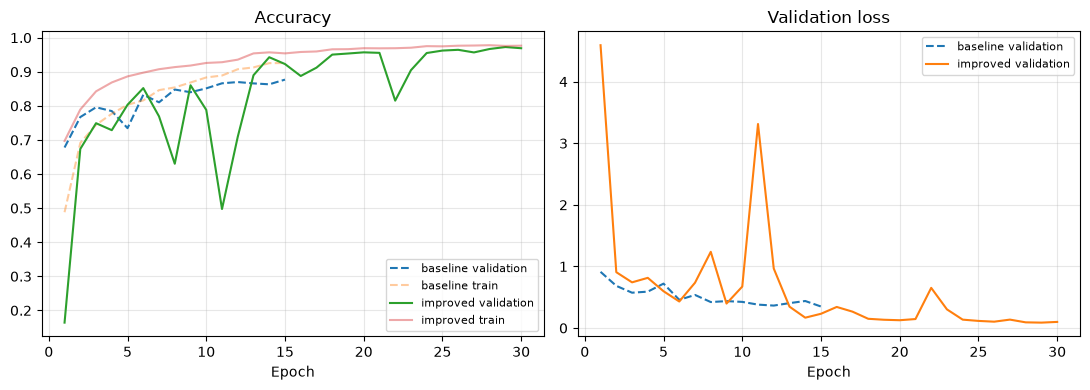

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, style in [("baseline", "--"), ("improved", "-")]:
    path = REPORTS_DIR / f"{name}_history.csv"
    if path.exists():
        h = pd.read_csv(path)
        axes[0].plot(h["epoch"] + 1, h["val_accuracy"], style, label=f"{name} validation")
        axes[0].plot(h["epoch"] + 1, h["accuracy"], style, alpha=0.4, label=f"{name} train")
        axes[1].plot(h["epoch"] + 1, h["val_loss"], style, label=f"{name} validation")
axes[0].set(title="Accuracy", xlabel="Epoch"); axes[1].set(title="Validation loss", xlabel="Epoch")
for ax in axes: ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "training_curves.png", dpi=150); plt.show()

## 📝 Observations
*Fill in after training:*
- Best validation accuracy, improved vs baseline: …
- Is the gap between training and validation accuracy smaller? Why?
- Training time and number of parameters compared with the baseline: …